In [1]:
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

In [2]:
import numpy as np
import os, yaml, glob

from matplotlib import pyplot as plt
from pylab import *

from tqdm import tqdm
from pathlib import Path

In [3]:
import torch 

In [4]:
import sys
sys.path.append('./code')

from torch.utils.data import DataLoader
from models import XASLightningModule
from data import XASGraphDataset, PrecomputedGraphDataset, collate_fn

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
nblocks, cutoff, threebody_cutoff = 3, 4.0, 4.0

In [6]:
GRID=np.linspace(9500-600, 9650-600, 1000)
energy_grid = GRID[333:733:2]

In [7]:
ROOT_PATH = './'

In [8]:
with open(ROOT_PATH + "/configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

### 1. Load xyz file and extract snapshots

In [9]:
import ase
from ase import io
from ase.data import atomic_numbers

In [10]:
import random

In [11]:
savepath = './tmp/'

In [12]:
replace_dict = {
    1: atomic_numbers['O'], 
    2: atomic_numbers['H'], 
    3: atomic_numbers['Zn'], 
    4: atomic_numbers['Cl'], 
} 

In [13]:
concentration = '2m'

In [14]:
xyzfile = ROOT_PATH + 'data/data-traj/zncl2-%s/zncl2.xyz'%concentration
data = ase.io.read(xyzfile, index=':')

num_O = sum(data[0].numbers == 1)
num_H = sum(data[0].numbers == 2)
num_Zn = sum(data[0].numbers == 3)
num_Cl = sum(data[0].numbers == 4)

data_sorted = []
for atoms in data: 
    atoms_sorted = atoms[data[0].numbers.argsort()]
    data_sorted.append(atoms_sorted)

new_numbers = [replace_dict[atom.number] for atom in data_sorted[0]]

for atoms in data_sorted:
    atoms.set_atomic_numbers(new_numbers)

In [15]:
interval = 100
n_select = 10
selected_idx = random.sample(range(len(data) // interval), n_select)  # choose 10 snapshots with 0.5 ns interval

In [16]:
for ii in tqdm(selected_idx) : 
    atoms = data_sorted[ii]
    for target_index in range(num_O + num_H, num_O + num_H + num_Zn):  
        new_order = [target_index] + [i for i in range(len(atoms)) if i != target_index]
        atoms_reordered = atoms[new_order]
        io.write(savepath + 'POSCAR_%s-site_%s'%(ii,target_index), atoms_reordered, format='vasp')    

100%|██████████| 10/10 [00:02<00:00,  3.90it/s]


### 2. Load POSCAR files

In [17]:
from pymatgen.core.structure import Structure

In [18]:
fn_poscars = glob.glob(savepath+"/POSCAR*")

In [19]:
structures = []
for fn in fn_poscars: 
    structures.append(Structure.from_file(fn))

In [20]:
len(structures)

180

In [21]:
spectra = np.zeros((len(structures), 2))

In [24]:
dataset = XASGraphDataset(structures, spectra, cutoff=cutoff)

In [25]:
torch.save({
    "graphs": [g for g, _, _ in dataset],
    "states": [s for _, s, _ in dataset],
    "spectra": [y for _, _, y in dataset]
}, savepath + "large-zncl2-%s_XASGraphDataset.pt"%concentration)

### 3. Load model

In [26]:
gnn_config = dict(
    nblocks = config['gnn']['nblocks'], 
    cutoff = config['gnn']['cutoff'], 
    threebody_cutoff = config['gnn']['threebody_cutoff']
)

head_config = dict(
    hidden_dims = config['head']['hidden_dims'], 
    output_size = config['head']['output_size'], 
    drop_rate = config['head']['drop_rate'], 
)

model = XASLightningModule(gnn_config, head_config, learning_rate=config['training']['lr'])

model.load_state_dict(torch.load(os.path.join('./model', "full_model.pth"), weights_only=True))

model = model.to(device)
model.eval()

XASLightningModule(
  (loss_fn): MSELoss()
  (gnn): XASGNN(
    (bond_expansion): BondExpansion(
      (rbf): SphericalBesselFunction()
    )
    (basis_expansion): SphericalBesselWithHarmonics(
      (shf): SphericalHarmonicsFunction()
      (sbf): SphericalBesselFunction()
    )
    (embedding): EmbeddingBlock(
      (activation): SiLU()
      (layer_node_embedding): Embedding(4, 64)
      (layer_edge_embedding): MLP(9 → 64, SiLU)
    )
    (three_body_interactions): ModuleList(
      (0-2): 3 x ThreeBodyInteractions(
        (update_network_atom): MLP(64 → 9, Sigmoid)
        (update_network_bond): GatedMLP(
          (layers): Sequential(
            (0): Linear(in_features=9, out_features=64, bias=False)
            (1): SiLU()
          )
          (gates): Sequential(
            (0): Linear(in_features=9, out_features=64, bias=False)
            (1): Sigmoid()
          )
        )
      )
    )
    (graph_layers): ModuleList(
      (0-2): 3 x M3GNetBlock(
        (activation):

### 4. Prediction

In [27]:
data = torch.load(savepath + "large-zncl2-%s_XASGraphDataset.pt"%concentration)
dataset = PrecomputedGraphDataset(data["graphs"], data["states"], data["spectra"])
dataloader = DataLoader(dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

/tmp/ipykernel_3637939/1874026518.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(savepath + "large-zncl2-%s_XASGraphDataset.pt"%concentration)


In [28]:
%%time

predictions = []

with torch.no_grad():   # disables gradient tracking
    for g, _, _ in dataloader:
        g = g.to(device) 
        spectra = model(g)

        predictions.append(spectra.cpu())
        # del spectra, g

# concatenate all predictions into one tensor
predictions = torch.cat(predictions, dim=0).numpy()

CPU times: user 23.3 s, sys: 7.07 s, total: 30.3 s
Wall time: 31.3 s


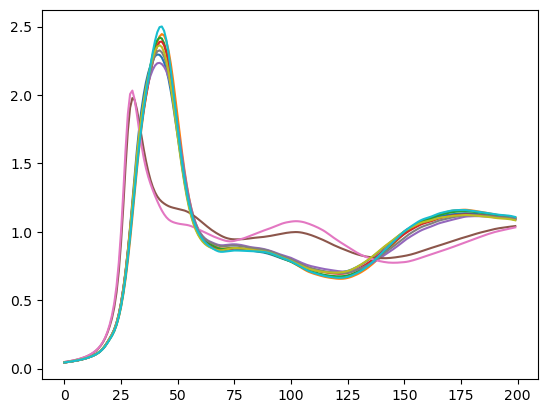

In [29]:
for spectrum in predictions[:10]: 
    plt.plot(range(len(spectrum)), spectrum)

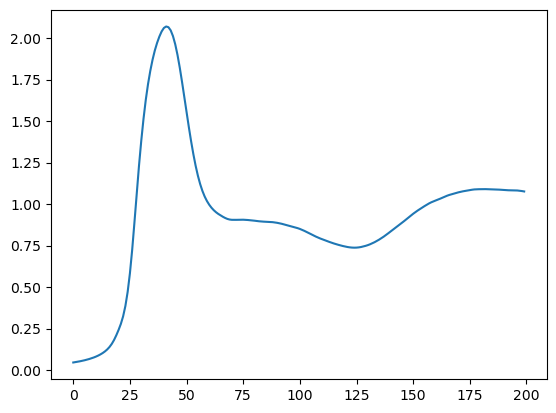

In [30]:
plt.plot(range(len(spectrum)), predictions.mean(axis=0))

In [31]:
# np.save(savepath + "large-zncl2-%s-predicted-sp.npy"%concentration, predictions)
# np.savetxt(savepath + "large-zncl2-%s-predicted-ave-sp.txt"%concentration, np.column_stack((energy_grid, predictions.mean(axis=0))))

## Monitor GPU usage

In [32]:
import gc

In [33]:
torch.cuda.empty_cache()

In [34]:
gc.collect()

4743

In [35]:
torch.cuda.ipc_collect()

In [36]:
print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")


0.021366596221923828 GB allocated
0.041015625 GB reserved
